# Project Overview: HR Analytics - Predicting Employee Attrition

## Introduction
Employee attrition is a significant cost to organizations, affecting productivity, morale, and recruitment budgets. This project provides a comprehensive end-to-end data science analysis to identify the primary drivers of turnover and build a predictive model to help HR departments intervene proactively.

## Objectives
- **Exploratory Data Analysis (EDA):** Identify correlations between demographics, compensation, and attrition.
- **Feature Engineering:** Clean and prepare organizational data for machine learning.
- **Predictive Modeling:** Train a Random Forest Classifier to identify at-risk employees.
- **Actionable Insights:** Translate model findings into executive-level retention strategies.

## Dataset
The analysis uses the IBM HR Analytics Employee Attrition & Performance dataset, covering 1,470 employees across various departments and job roles.

### 1. Data Loading and Initial Inspection
We will start by importing the necessary libraries and loading the dataset to understand its structure.

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('/content/WA_Fn-UseC_-HR-Employee-Attrition.csv')

# Display basic information
display(df.head())
print(df.info())

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

### 2. Exploratory Data Analysis (EDA)
Let's visualize the target variable `Attrition` and check how it correlates with key factors like Age, Monthly Income, and Job Role.

/tmp/ipykernel_6297/1690703525.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Attrition', data=df, palette='viridis')


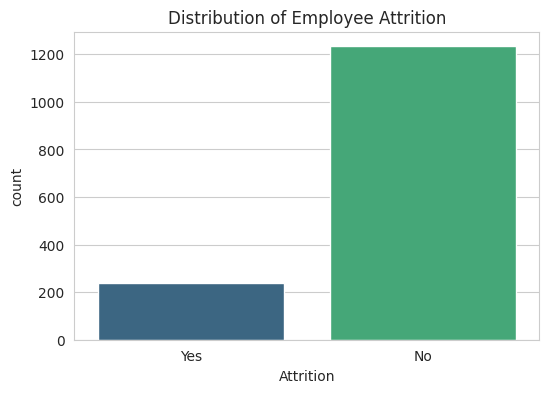

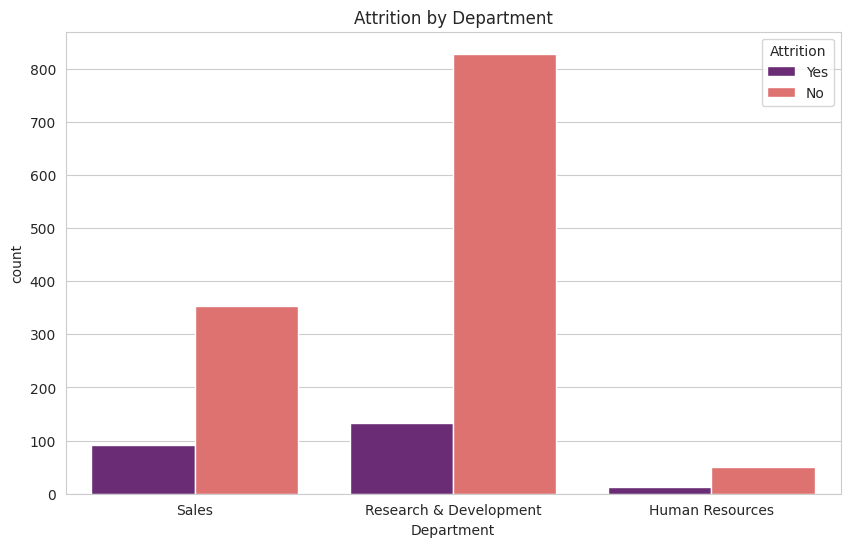

In [17]:
sns.set_style('whitegrid')

# Plotting the distribution of Attrition
plt.figure(figsize=(6,4))
sns.countplot(x='Attrition', data=df, palette='viridis')
plt.title('Distribution of Employee Attrition')
plt.show()

# Attrition by Department
plt.figure(figsize=(10,6))
sns.countplot(x='Department', hue='Attrition', data=df, palette='magma')
plt.title('Attrition by Department')
plt.show()

### 3. Deep Dive: Income vs. Attrition
Salary is often a primary driver for attrition. Let's look at the distribution of Monthly Income for those who stayed versus those who left.

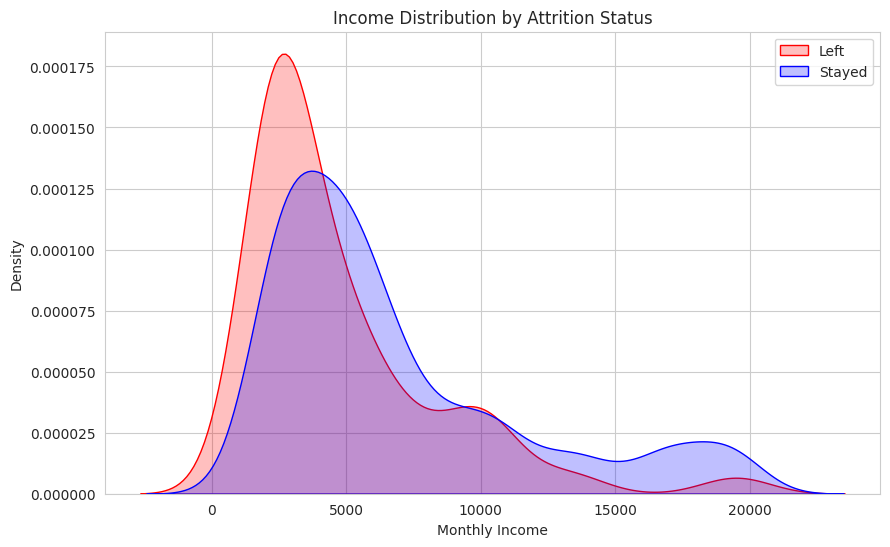

In [18]:
plt.figure(figsize=(10,6))
sns.kdeplot(df[df['Attrition'] == 'Yes']['MonthlyIncome'], label='Left', fill=True, color='red')
sns.kdeplot(df[df['Attrition'] == 'No']['MonthlyIncome'], label='Stayed', fill=True, color='blue')
plt.title('Income Distribution by Attrition Status')
plt.xlabel('Monthly Income')
plt.legend()
plt.show()

### 4. Correlation Analysis
To understand the relationship between numerical variables, we'll generate a heatmap. This helps identify which factors have the strongest associations.

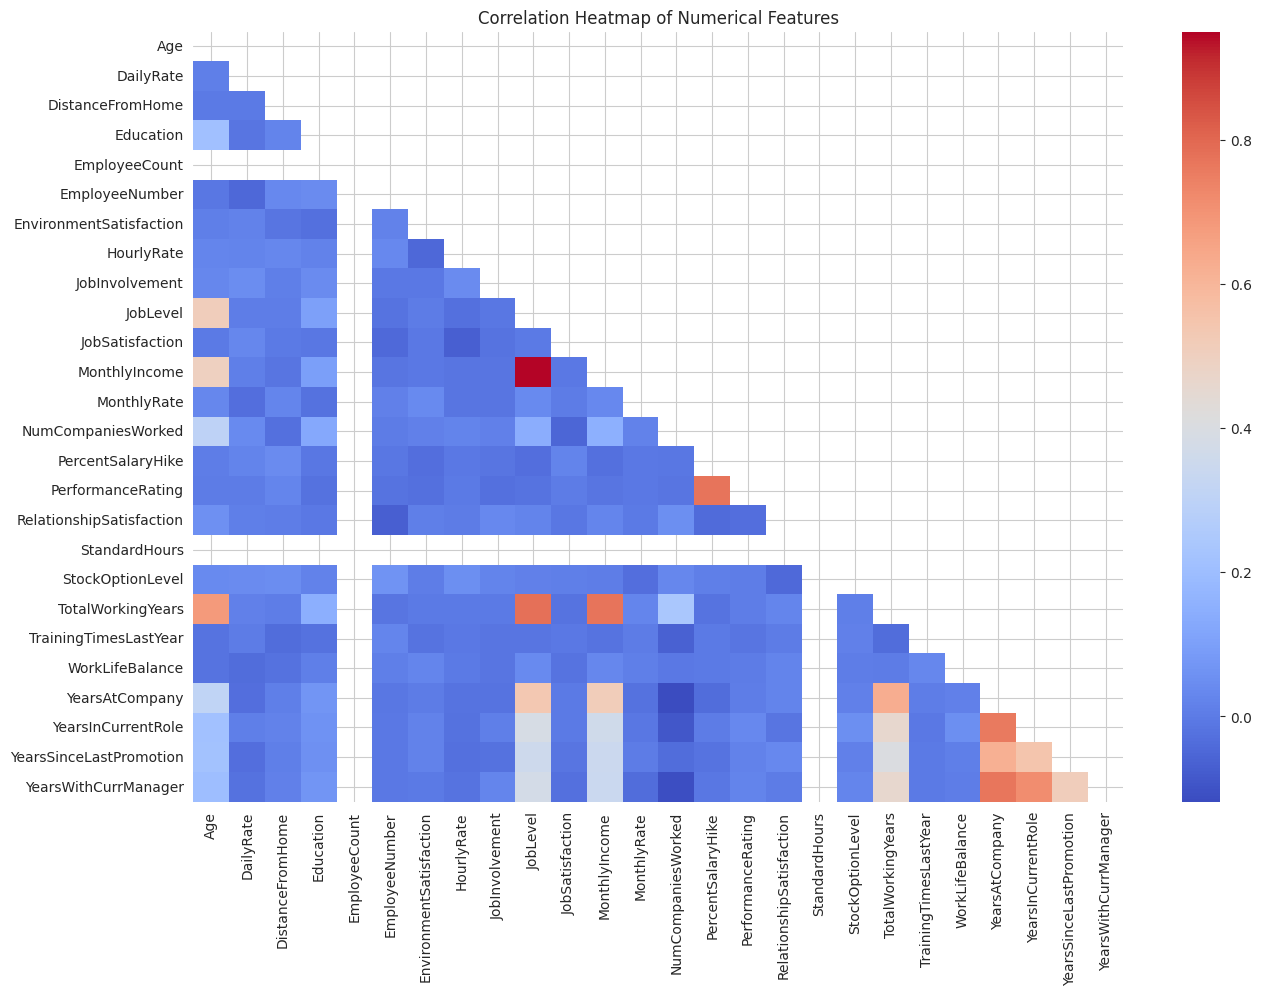

In [19]:
plt.figure(figsize=(15, 10))
numeric_df = df.select_dtypes(include=[np.number])
mask = np.triu(np.ones_like(numeric_df.corr(), dtype=bool))
sns.heatmap(numeric_df.corr(), mask=mask, annot=False, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

### 5. Impact of Overtime and Work-Life Balance
Let's analyze how overtime work affects attrition, as this is often a significant predictor.

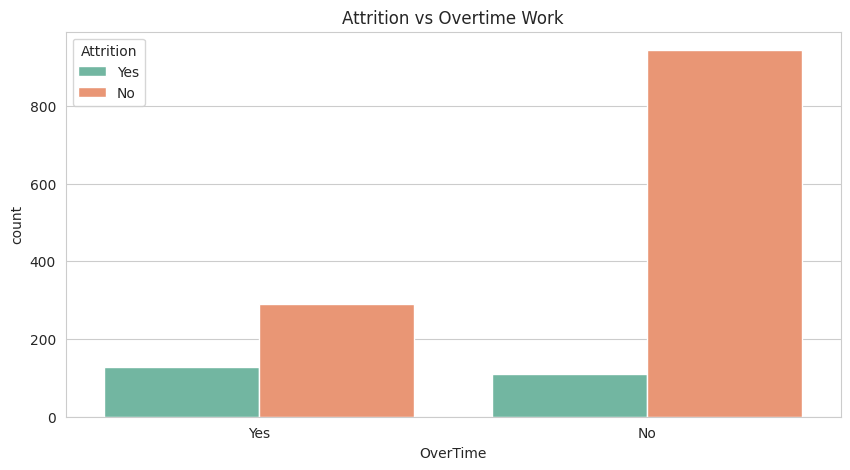

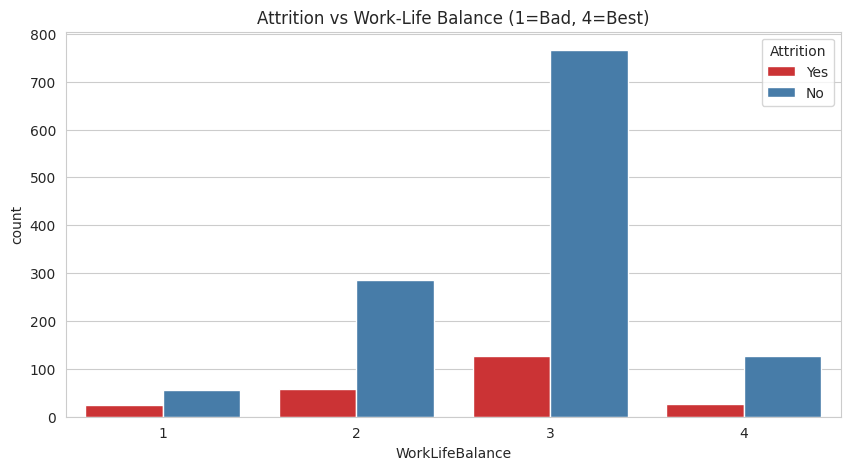

In [20]:
plt.figure(figsize=(10,5))
sns.countplot(x='OverTime', hue='Attrition', data=df, palette='Set2')
plt.title('Attrition vs Overtime Work')
plt.show()

# WorkLifeBalance vs Attrition
plt.figure(figsize=(10,5))
sns.countplot(x='WorkLifeBalance', hue='Attrition', data=df, palette='Set1')
plt.title('Attrition vs Work-Life Balance (1=Bad, 4=Best)')
plt.show()

### 6. Data Cleaning and Preprocessing
Before modeling, we must remove columns with zero variance (like `EmployeeCount` and `StandardHours`) and encode our target variable `Attrition` into a binary format.

In [21]:
# Drop redundant columns with no predictive power and redundant rate columns to prevent leakage/noise
df_model = df.drop(columns=['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber',
                            'DailyRate', 'HourlyRate', 'MonthlyRate'])

# Convert target to binary
df_model['Attrition'] = df_model['Attrition'].map({'Yes': 1, 'No': 0})

# Quick check on Overtime percentages as discussed
print("Attrition Percentage by Overtime Status:")
print(df.groupby('OverTime')['Attrition'].value_counts(normalize=True) * 100)

Attrition Percentage by Overtime Status:
OverTime  Attrition
No        No           89.563567
          Yes          10.436433
Yes       No           69.471154
          Yes          30.528846
Name: proportion, dtype: float64


### 7. Predictive Modeling & Feature Importance
We will use a Random Forest Classifier to predict attrition. This model is ideal for portfolios because it allows us to extract 'Feature Importance', showing exactly which factors (like OverTime or Income) drive the decision to leave.

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# One-hot encode categorical variables
X = pd.get_dummies(df_model.drop('Attrition', axis=1), drop_first=True)
y = df_model['Attrition']

# Split data with stratification to maintain class ratios
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Initialize and train model with class_weight='balanced' to handle the 16% attrition rate imbalance
rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)

# Evaluate - look for improved Recall in class 1
y_pred = rf.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.99      0.92       247
           1       0.62      0.11      0.18        47

    accuracy                           0.85       294
   macro avg       0.74      0.55      0.55       294
weighted avg       0.82      0.85      0.80       294



/tmp/ipykernel_6297/3900195388.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10), palette='magma')


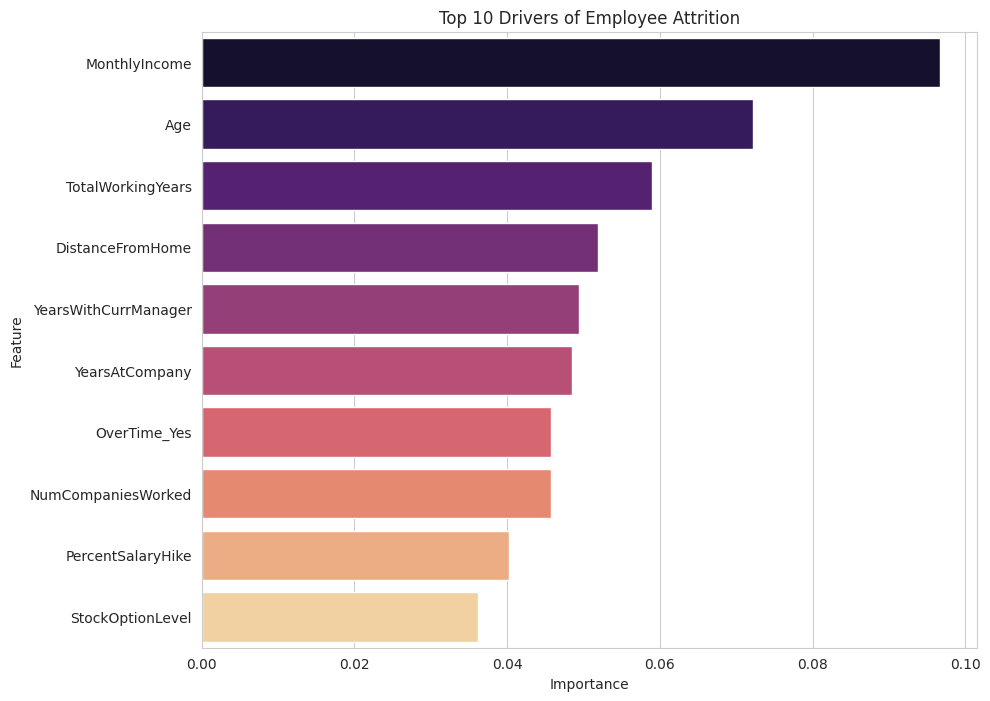

In [23]:
# Plotting Feature Importance
importances = rf.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10), palette='magma')
plt.title('Top 10 Drivers of Employee Attrition')
plt.show()

### 8. Executive Recommendations
Based on the data analysis and predictive modeling, here are the strategic recommendations to reduce employee attrition:

1.  **Compensation Restructuring**: Since `MonthlyIncome` is the top driver, the company should conduct a market salary benchmark to ensure competitive pay, especially for entry-to-mid-level roles where attrition is highest.
2.  **Overtime Management**: Employees working overtime are 3x more likely to leave (30.5% vs 10.4%). Implementing a 'Compensatory Off' policy or hiring additional staff to distribute workload could mitigate burnout.
3.  **Career Pathing for Young Talent**: `Age` and `TotalWorkingYears` are significant predictors. Structured mentorship programs and clear internal promotion pathways can help retain younger talent who may otherwise leave for 'faster' growth elsewhere.
4.  **Work-Life Balance Initiatives**: For employees scoring a 1 on Work-Life Balance, targeted wellness programs or flexible remote-work options should be introduced.